# Validating My Neural Network

In this notebook, I’m comparing my neural network built from scratch with NumPy to the same network implemented with PyTorch Lightning.

---

## What We’ll Do

1. Generate a toy dataset using `sklearn`’s `make_moons` function.
2. Build a neural network from scratch with NumPy.
3. Build the same neural network using PyTorch Lightning.
4. Initialize both models with the same parameters for a fair comparison.
5. Train both networks, record the loss at each epoch, and plot it.
6. Compare the performance of the custom network to the PyTorch Lightning version.

---

## Neural Network Architecture

The network has 2 input features and 2 dense (fully connected) hidden layers with 8 and 4 units, respectively. Each hidden layer uses a ReLU activation function. The output layer has 1 unit and uses a sigmoid activation function.

---

## Dataset

The dataset is generated using `sklearn`’s `make_moons` function and split 80/20 for training and testing. Mini-batches of 100 samples are created to train the network efficiently and process the data using vectorized operations, following the approach suggested by Andrew Ng.

---

## Optimization

My custom neural network uses plain gradient descent to update its parameters, while the PyTorch Lightning model uses `torch.optim.SGD`.


In [1]:
import my_ml_nn
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import copy

In [2]:
x_train, x_test, y_train, y_test = my_ml_nn.create_test_data()

nn_parameters = my_ml_nn.init_parameters(x_train.shape[0])
nn_parameters_for_my_own_nn = copy.deepcopy(nn_parameters)
nn_parameters_for_my_pytorch_nn = copy.deepcopy(nn_parameters)

epochs = 3000

In [3]:
loss_recorder_my_nn = my_ml_nn.fitting_my_nn(x_train, y_train, nn_parameters_for_my_own_nn, epochs)

In [4]:
import my_pytorch_nn as ref_mdl

In [5]:
ref_model, trainer, loss_recorder_lightning = ref_mdl.train_my_ref_nn(x_train.T,y_train.T, epochs, nn_parameters_for_my_pytorch_nn)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | layer1  | Linear  | 24     | train
1 | layer2  | Linear  | 36     | train
2 | output  | Linear  | 5      | train
3 | loss_fn | BCELoss | 0      | train
--------------------------------------------
65        Trainable params
0         Non-trainable params
65        Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
/Users/botang/Documents/Conda3/envs/MyCondaEnv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a 

Epoch 2999: 100%|██████████| 8/8 [00:00<00:00, 79.07it/s, v_num=16] 

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 2999: 100%|██████████| 8/8 [00:00<00:00, 70.81it/s, v_num=16]


In [6]:
train_loss = trainer.callback_metrics["train_loss"].item()
print("Final train loss calculated by the pytorch lightning nn:", train_loss)
print("Final train loss calcllated by my nn from scratch", loss_recorder_my_nn[-1])

Final train loss calculated by the pytorch lightning nn: 0.07198704034090042
Final train loss calcllated by my nn from scratch 0.07198803367921672


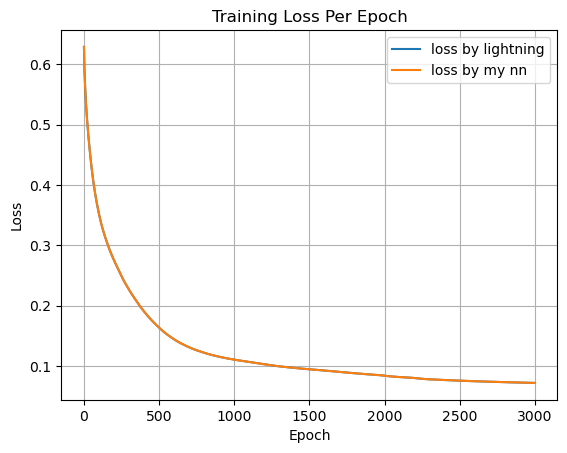

In [7]:
plt.plot(loss_recorder_lightning.epoch_losses, label = 'loss by lightning')
plt.plot(loss_recorder_my_nn, label = 'loss by my nn')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Per Epoch")
plt.grid(True)
plt.legend()
plt.show()

# 🎉 Success! 🎉

🚀💯 🚀💯 🚀💯 🚀💯 🚀💯   

My neural network from scratch is performing really well, almost matching the PyTorch Lightning version! 🥳✨  

Time to celebrate this little victory! 

🎊🎈 🎊🎈 🎊🎈 🎊🎈 🎊🎈


In [10]:
import numpy as np

y_hat = my_ml_nn.my_nn_predict(x_train, nn_parameters_for_my_own_nn)
y_hat = (y_hat >= 0.5).astype(float) 

accuracy = np.sum(y_hat == y_train) / y_hat.shape[1]
print(f'Predict accuracy of train data is {accuracy}')

y_hat = my_ml_nn.my_nn_predict(x_test, nn_parameters_for_my_own_nn)
y_hat = (y_hat >= 0.5).astype(float)

accuracy = np.sum(y_hat == y_test) / y_hat.shape[1]
print(f'Predict accuracy of test data is {accuracy}')


Predict accuracy of train data is 0.9775
Predict accuracy of test data is 0.995


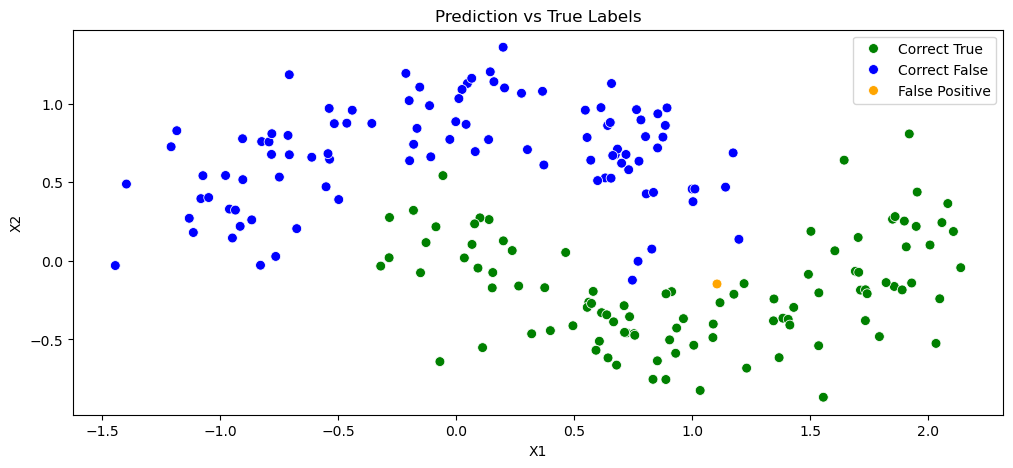

In [9]:
import seaborn as sns

category = np.where((y_hat == y_test) & (y_test == 1), "Correct True", 
                    np.where((y_hat == y_test) & (y_test == 0), "Correct False",
                    np.where((y_hat != y_test) & (y_test == 1), "False Negative",
                     "False Positive")))

category = category.reshape(-1)

plt.figure(figsize = (12,5))
sns.scatterplot(
    x = x_test[0,:].T,
    y = x_test[1,:].T,
    hue = category,
    palette = {"Correct True":"green", "Correct False": "blue", "False Negative":"red", "False Positive":"orange"},
    s=50
)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Prediction vs True Labels")
plt.show()
